In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import time

BASE = Path(r"C:\Users\sbhat\OneDrive - Arizona State University\Documents\Arizona State University Courses\Data Mining\home work 3\kmeans_data (1)")

DATA_PATH  = BASE / "data.csv"
LABEL_PATH = BASE / "label.csv"

print("DATA_PATH exists:", DATA_PATH.exists())
print("LABEL_PATH exists:", LABEL_PATH.exists())

X_df = pd.read_csv(DATA_PATH, header=None)
y_sr = pd.read_csv(LABEL_PATH, header=None).iloc[:, 0]
print("Data loaded successfully!")



DATA_PATH exists: True
LABEL_PATH exists: True
Data loaded successfully!


In [3]:
X = X_df.values.astype(float)
X = X / 255.0 if X.max() > 1.0 else X
y = y_sr.values.astype(int)
K = len(np.unique(y))
print("Data shape:", X.shape, " | K =", K)



Data shape: (10000, 784)  | K = 10


In [4]:
def euclidean_distance(a, b):
    a2 = np.sum(a*a, axis=1, keepdims=True)
    b2 = np.sum(b*b, axis=1, keepdims=True).T
    ab = a @ b.T
    return np.maximum(a2 + b2 - 2*ab, 0.0)

def cosine_distance(a, b, eps=1e-12):
    a_norm = a / (np.linalg.norm(a, axis=1, keepdims=True) + eps)
    b_norm = b / (np.linalg.norm(b, axis=1, keepdims=True) + eps)
    sim = a_norm @ b_norm.T
    return 1.0 - sim

def jaccard_distance(a, b, eps=1e-12):
    a_exp = a[:, None, :]
    b_exp = b[None, :, :]
    numerator = np.sum(np.minimum(a_exp, b_exp), axis=2)
    denominator = np.sum(np.maximum(a_exp, b_exp), axis=2) + eps
    sim = numerator / denominator
    return 1.0 - sim


In [5]:
def kmeans_generic(X, k, dist_fn, max_iter=100, tol=1e-6):
    n, d = X.shape
    rng = np.random.default_rng(0)
    centroids = X[rng.choice(n, k, replace=False)]
    prev_centroids = centroids.copy()
    sse_prev = np.inf
    t0 = time.time()

    for it in range(max_iter):
        D = dist_fn(X, centroids)
        labels = np.argmin(D, axis=1)
        sse = float(np.sum(D[np.arange(n), labels]))
        new_centroids = np.zeros_like(centroids)
        for j in range(k):
            pts = X[labels == j]
            new_centroids[j] = X[rng.integers(0, n)] if len(pts) == 0 else pts.mean(axis=0)
        if np.allclose(new_centroids, centroids, atol=tol):
            break
        if sse > sse_prev:
            break
        centroids = new_centroids
        sse_prev = sse
    return {"labels": labels, "sse": sse, "iterations": it+1, "time_sec": round(time.time()-t0, 3)}

def cluster_majority_accuracy(true_labels, cluster_labels, k):
    acc = 0
    for j in range(k):
        idx = np.where(cluster_labels == j)[0]
        if len(idx) == 0: continue
        maj = Counter(true_labels[idx]).most_common(1)[0][0]
        acc += np.sum(true_labels[idx] == maj)
    return acc / len(true_labels)


In [6]:
subset_n = 3000  # sample size for speed
if subset_n and X.shape[0] > subset_n:
    np.random.seed(42)
    idx = np.random.choice(X.shape[0], subset_n, replace=False)
    X_run, y_run = X[idx], y[idx]
else:
    X_run, y_run = X, y

metrics = {"euclidean": euclidean_distance, "cosine": cosine_distance, "jaccard": jaccard_distance}
rows = []
for name, fn in metrics.items():
    out = kmeans_generic(X_run, K, fn)
    acc = cluster_majority_accuracy(y_run, out["labels"], K)
    rows.append({"metric": name, "SSE": out["sse"], "accuracy": round(acc, 4),
                 "iterations": out["iterations"], "time_sec": out["time_sec"]})
results = pd.DataFrame(rows)
display(results)

,metric,SSE,accuracy,iterations,time_sec
0,euclidean,116603.409664,0.6143,47,2.302
1,cosine,738.095896,0.6260,27,1.538
2,jaccard,1939.451877,0.4687,2,1.018


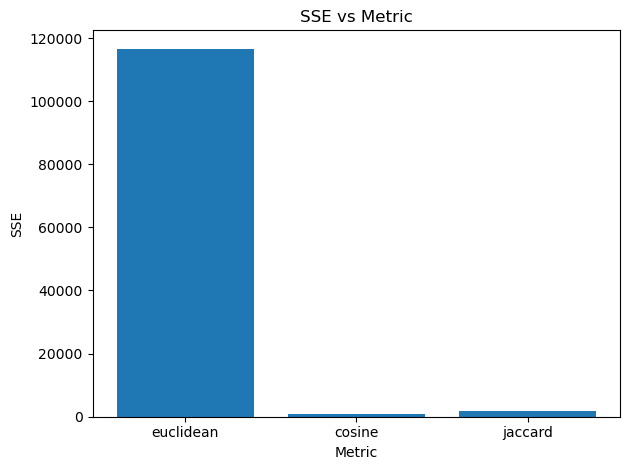

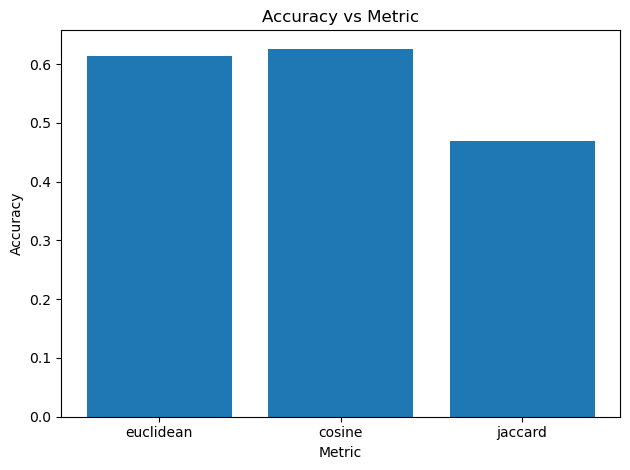

✅ Done! Results saved in: C:\Users\sbhat\OneDrive - Arizona State University\Documents\Arizona State University Courses\Data Mining\home work 3\New\task1_outputs


In [7]:
out_dir = Path("task1_outputs"); out_dir.mkdir(exist_ok=True)
results.to_csv(out_dir / "task1_kmeans_comparison.csv", index=False)

plt.bar(results["metric"], results["SSE"])
plt.title("SSE vs Metric"); plt.xlabel("Metric"); plt.ylabel("SSE")
plt.tight_layout(); plt.savefig(out_dir / "task1_sse_vs_metric.png"); plt.show()

plt.bar(results["metric"], results["accuracy"])
plt.title("Accuracy vs Metric"); plt.xlabel("Metric"); plt.ylabel("Accuracy")
plt.tight_layout(); plt.savefig(out_dir / "task1_accuracy_vs_metric.png"); plt.show()

print("✅ Done! Results saved in:", out_dir.resolve())

In [9]:
with open(r"C:\Users\sbhat\OneDrive - Arizona State University\Documents\Arizona State University Courses\Data Mining\home work 3\New\task1_outputs\task1_report_text.txt",
          encoding="utf-8", errors="ignore") as f:
    print(f.read())


Q1  SSE comparison (lower is better):
   cosine: SSE = 738.10
   euclidean: SSE = 116603.41
   jaccard: SSE = 1939.45
Conclusion: cosine produced the lowest SSE.

Q2  Accuracy comparison (higher is better):
   cosine: accuracy = 0.6260
   euclidean: accuracy = 0.6143
   jaccard: accuracy = 0.4687
Conclusion: cosine achieved the highest accuracy.

Q3  Convergence (iterations / time):
   cosine: iterations = 27, time = 1.538 s
   euclidean: iterations = 47, time = 2.302 s
   jaccard: iterations = 2, time = 1.018 s



In [10]:
from pathlib import Path
import pandas as pd

out_dir = Path("task1_outputs")
df = pd.read_csv(out_dir / "task1_kmeans_comparison.csv").sort_values("metric")

best_sse_metric = df.loc[df["SSE_like" if "SSE_like" in df.columns else "SSE"].idxmin(), "metric"]
best_acc_metric = df.loc[df["majority_vote_accuracy" if "majority_vote_accuracy" in df.columns else "accuracy"].idxmax(), "metric"]

lines = []
lines.append("Q1 — SSE comparison (lower is better):\n")
for _, r in df.iterrows():
    sse_col = "SSE_like" if "SSE_like" in df.columns else "SSE"
    lines.append(f"  • {r['metric']}: SSE = {r[sse_col]:.2f}\n")
lines.append(f"Conclusion: {best_sse_metric} produced the lowest SSE.\n\n")

acc_col = "majority_vote_accuracy" if "majority_vote_accuracy" in df.columns else "accuracy"
lines.append("Q2 — Accuracy comparison (higher is better):\n")
for _, r in df.iterrows():
    lines.append(f"  • {r['metric']}: accuracy = {r[acc_col]:.4f}\n")
lines.append(f"Conclusion: {best_acc_metric} achieved the highest accuracy.\n\n")

lines.append("Q3 — Convergence (iterations / time):\n")
for _, r in df.iterrows():
    lines.append(f"  • {r['metric']}: iterations = {int(r['iterations'])}, time = {r['time_sec']} s\n")

with open(out_dir / "task1_report_text.txt", "w") as f:
    f.writelines(lines)

print("Wrote:", (out_dir / "task1_report_text.txt").resolve())


Wrote: C:\Users\sbhat\OneDrive - Arizona State University\Documents\Arizona State University Courses\Data Mining\home work 3\New\task1_outputs\task1_report_text.txt
